Visualisation des résultats sur des instances générées aléatoirement

In [94]:
%load_ext autoreload
%autoreload 2

import gurobipy as gp
from gurobipy import GRB

from matplotlib import pyplot as plt

from first_model import Instance, Solution, Model
from utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# I. Test de plusieurs scénarios pour le modèle, avec et sans worker compétent pour les tâches

#### Instance générée aléatoirement

## I.1 Au moins un worker compétent pour chaque métier

In [95]:
instance_generated = Instance()
instance_generated.from_random(at_least_a_worker_have_competence_for_each_profession=True, seed=42)
print(instance_generated)


 ===== Start of Instance: =====
Number of jobs: 2
Number of professions: 4
Number of tasks per profession: [2 2 2 3]
Max number of operations per Jobs: 4
Total number of tasks: 9
Total number of workers: 3
Task to profession mapping:
{0: 0, 1: 0, 2: 1, 3: 1, 4: 2, 5: 2, 6: 3, 7: 3, 8: 3}
Worker levels: shape=(3, 4)
 [[4 1 2 3]
 [1 4 2 1]
 [4 4 4 1]]
Job difficulties: shape= (2,)
[3 4]
Task difficulties: shape= (9,)
[4 3 4 1 4 3 3 2 1]
Task processing times: shape= (9, 3)
[[ 7.         10.37096069  3.66332982]
 [19.         22.80443897 18.75067743]
 [11.         16.47429815 -1.        ]
 [11.         15.23768898  5.99833539]
 [ 4.          5.53398379  3.23677202]
 [ 8.          9.61695913  5.52984797]
 [ 3.          3.62075618 -1.        ]
 [ 2.          2.7148648   1.46676289]
 [12.         15.8394995  11.15964244]]
Jobs structure: len= 2
Job 0 : 	O_(0,0) = 3 	O_(0,1) = 7 	O_(0,2) = 6 
Job 1 : 	O_(1,0) = 8 	O_(1,1) = 7 	O_(1,2) = 4 

Precedence constraints: shape= (2, 4, 4)
[[[0. 1. 0

Visualisation des opérateurs qualifiés pour chaque opération, on vient bien que toutes les opérations ont au moins un opérateur qualifié pour les faire

In [96]:
instance_generated.qualified_workers_for_task(verbose=True)     

J1:  (1,1): [1, 2, 3] 	 (1,2): [1] 	 (1,3): [1] 	

J2:  (2,1): [1, 2, 3] 	 (2,2): [1] 	 (2,3): [3] 	



[[[1, 2, 3], [1], [1]], [[1, 2, 3], [1], [3]]]

In [97]:
model = Model(instance_generated)
s = model.solve(objective="makespan", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 1.0001e-06
ici ->  2
nObjectives 2
nSolutions 3


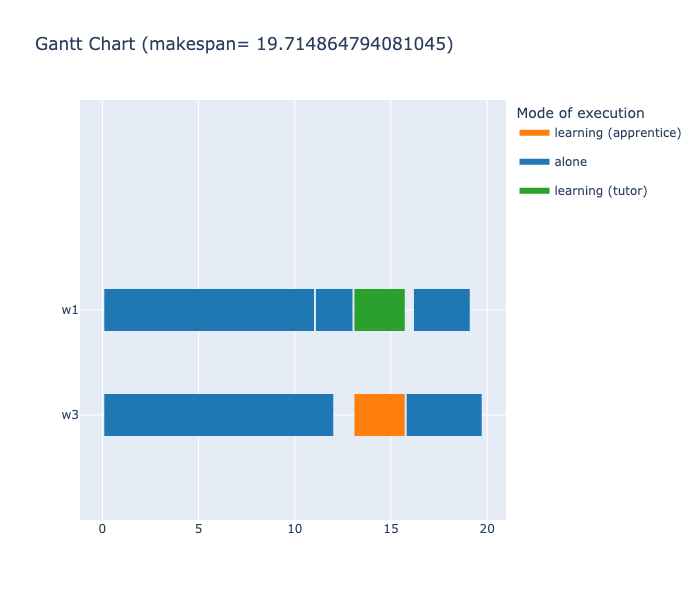

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.100000,11.000000,11.000000,11.000000,"(1,1)",J1,alone,1,1,3.0,1.0
1,w1,11.100000,13.000000,13.000000,2.000000,"(1,2)",J1,alone,3,2,7.0,3.0
2,w1,13.100000,15.714865,15.714865,2.714865,"(2,2)",J2,learning (tutor),3,2,7.0,3.0
3,w1,16.194209,19.094209,19.094209,3.000000,"(1,3)",J1,alone,3,3,6.0,3.0
4,w3,0.100000,12.000000,12.000000,12.000000,"(2,1)",J2,alone,1,1,8.0,3.0
5,w3,13.100000,15.714865,15.714865,2.714865,"(2,2)",J2,learning (apprentice),1,2,7.0,3.0
6,w3,15.814865,19.714865,19.714865,4.000000,"(2,3)",J2,alone,4,4,4.0,2.0


In [98]:
gantt_chart(s, instance_generated, color=3, render= "notebook", verbose=False, separate_little=True)

Fonction `do_solo_without_level(instance, solution)` pour savoir si dans une solution il y'a eu un worker non compétnent qui a été assigné à une tâche et affihce les pénalitées associées à cette tache

In [99]:
def do_solo_without_level(instance, solution):
    # Les indices commencent à 0 
    x, y, z = [], [], []

    for i in range(len(solution.penalty_levels)):
        for j in range(len(solution.penalty_levels[i])):
            # 0.5 car pb de précision dans les calculs
            if solution.penalty_levels[i, j] > 0.5: #si il y a une pénalité on la stocke pour l'afficher ensuite
                print(f"Opération {j} du job {i} a une pénalité de {solution.penalty_levels[i, j]}")
                x.append(i)
                y.append(j)
                z.append(solution.penalty_levels[i, j])

    if len(x) > 0:
        z = np.array(z)
        plt.scatter(x, y, s=z*500)
        plt.xticks(range(instance.nb_jobs))
        plt.yticks(range(instance.max_nb_operations))
        plt.xlabel("Job")
        plt.ylabel("Opération")
        plt.title("Pénalités pour les opérations faites en solo par un worker qui n'a pas le niveau requis")
        plt.grid()
        plt.show()
    else :
        print("Aucune opération n'a été faite en solo par un worker qui n'a pas le niveau requis, il n'y a donc aucune pénalité à afficher.")

In [100]:
do_solo_without_level(instance_generated, s)

Aucune opération n'a été faite en solo par un worker qui n'a pas le niveau requis, il n'y a donc aucune pénalité à afficher.


## I.1a Avec la même instance mais en refusant les taches d'enseignement (teaching tasks) :

In [101]:
s = Model(instance_generated)
s = model.solve(objective="makespan", weight=[0, 0, 0], priority=[2, 1, 0], constraints_config={"no_teaching_tasks": True}, verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 1.0
ici ->  2
nObjectives 2
nSolutions 4


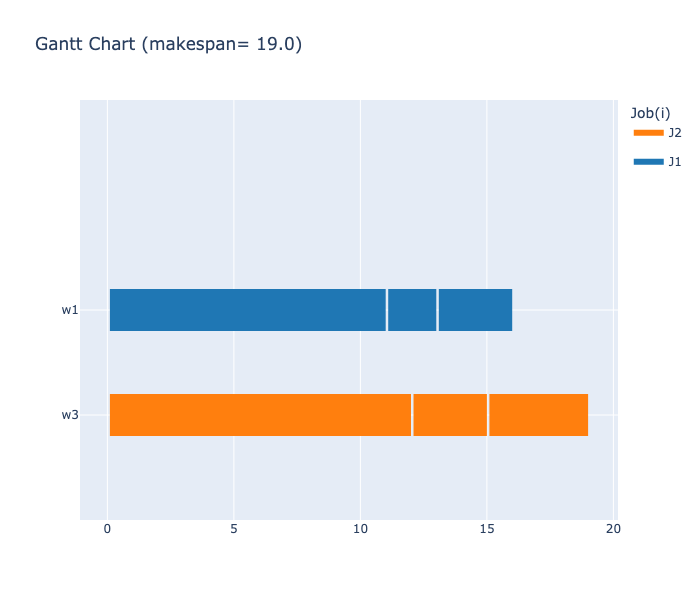

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.1,11.0,11.0,11.0,"(1,1)",J1,alone,1,1,3.0,1.0
1,w1,11.1,13.0,13.0,2.0,"(1,2)",J1,alone,3,2,7.0,3.0
2,w1,13.1,16.0,16.0,3.0,"(1,3)",J1,alone,3,3,6.0,3.0
3,w3,0.1,12.0,12.0,12.0,"(2,1)",J2,alone,1,1,8.0,3.0
4,w3,12.1,15.0,15.0,3.0,"(2,2)",J2,alone without levels,1,2,7.0,3.0
5,w3,15.1,19.0,19.0,4.0,"(2,3)",J2,alone,4,4,4.0,2.0


In [102]:
gantt_chart(s, instance_generated, color=2, render= "notebook", verbose=False, separate_little=True)

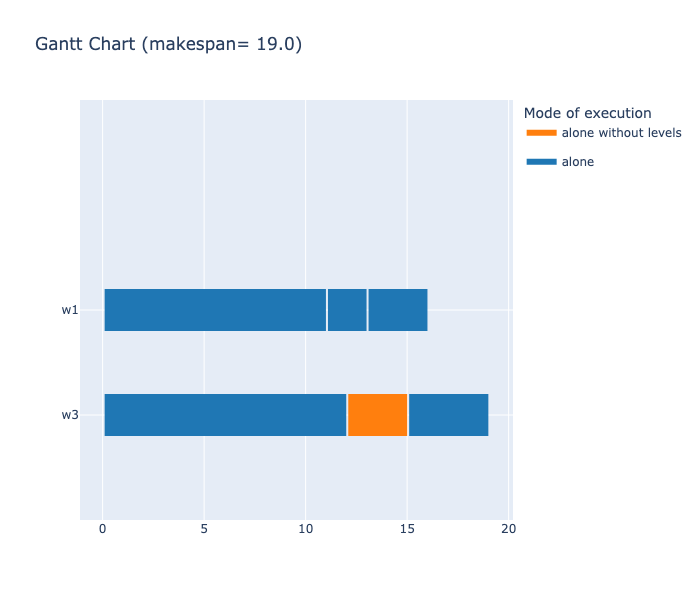

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.1,11.0,11.0,11.0,"(1,1)",J1,alone,1,1,3.0,1.0
1,w1,11.1,13.0,13.0,2.0,"(1,2)",J1,alone,3,2,7.0,3.0
2,w1,13.1,16.0,16.0,3.0,"(1,3)",J1,alone,3,3,6.0,3.0
3,w3,0.1,12.0,12.0,12.0,"(2,1)",J2,alone,1,1,8.0,3.0
4,w3,12.1,15.0,15.0,3.0,"(2,2)",J2,alone without levels,1,2,7.0,3.0
5,w3,15.1,19.0,19.0,4.0,"(2,3)",J2,alone,4,4,4.0,2.0


In [103]:
gantt_chart(s, instance_generated, color=3, render= "notebook", verbose=False, separate_little=True)

- On peut voir à présent **qu'aucune tache d'enseignement n'est faite**, et que **une opération est faite par un worker solo non compétent**, ce qui engendre une pénalité
- **La valeur du makespan est inchangée**
- j'ai passé **1 heure :(** à comprendre pourquoi un opérateur a fait une tache en solo sans y avoir le niveau alors que dans l'instance j'ai mis qu'il existe un opérateur compétent pour chaque corps de métier.
- Comme un job doit etre affecté entierement à un worker, en enlevant apprentissage, $w_3$ doit faire la tache seul, mme s'il n'a pas le niveau et que $w_1$ a le niveau. Car $w_1$ et $w_2$ n'ont pas le niveau pour finir $J_2$
- C'est pouquoi on a pas le choix que d'affecter cette opération à une personne non comptétente, ce qui engendre une pénalité

Opération 1 du job 1 a une pénalité de 1.0


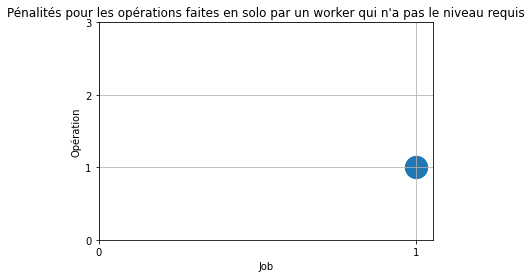

In [104]:
do_solo_without_level(instance_generated, s)

- On voit que $O_{11}$ à généré une pénalité de 1, donc l'opérateur affecté avait une difference de 1 avec le niveau de  difficulté de la tache

## I.2 Sans forcer le fait qu'il doit y avoir au moins un worker compétent pour chaque métier

In [105]:
instance_generated = Instance()
instance_generated.from_random(at_least_a_worker_have_competence_for_each_profession=False, seed=42)
print(instance_generated)


 ===== Start of Instance: =====
Number of jobs: 2
Number of professions: 4
Number of tasks per profession: [2 2 2 3]
Max number of operations per Jobs: 4
Total number of tasks: 9
Total number of workers: 3
Task to profession mapping:
{0: 0, 1: 0, 2: 1, 3: 1, 4: 2, 5: 2, 6: 3, 7: 3, 8: 3}
Worker levels: shape=(3, 4)
 [[2 2 2 2]
 [2 2 2 1]
 [3 2 2 2]]
Job difficulties: shape= (2,)
[3 4]
Task difficulties: shape= (9,)
[4 3 4 1 4 3 3 2 1]
Task processing times: shape= (9, 3)
[[ 7.         10.37096069  3.66332982]
 [19.         22.80443897 18.75067743]
 [11.         16.47429815 -1.        ]
 [11.         15.23768898  5.99833539]
 [ 4.          5.53398379  3.23677202]
 [ 8.          9.61695913  5.52984797]
 [ 3.          3.62075618 -1.        ]
 [ 2.          2.7148648   1.46676289]
 [12.         15.8394995  11.15964244]]
Jobs structure: len= 2
Job 0 : 	O_(0,0) = 3 	O_(0,1) = 7 	O_(0,2) = 6 
Job 1 : 	O_(1,0) = 8 	O_(1,1) = 7 	O_(1,2) = 4 

Precedence constraints: shape= (2, 4, 4)
[[[0. 1. 0

Visualisation des opérateurs qualifiés pour chaque opération, on vient bien que pour certaines opérations il y a des workers non qualifiées.

In [106]:
instance_generated.qualified_workers_for_task(verbose=True)

J1:  (1,1): [1, 2, 3] 	 (1,2): [1, 3] 	 (1,3): [] 	

J2:  (2,1): [1, 2, 3] 	 (2,2): [1, 3] 	 (2,3): [] 	



[[[1, 2, 3], [1, 3], []], [[1, 2, 3], [1, 3], []]]

In [107]:
model = Model(instance_generated)
s = model.solve(objective="makespan", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 3.0003010000000003
ici ->  2
nObjectives 2
nSolutions 5


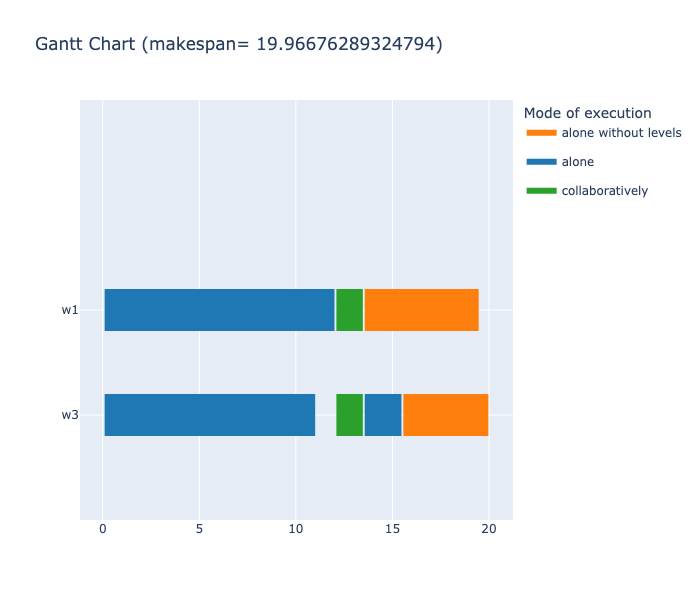

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.100000,12.000000,12.000000,12.000000,"(2,1)",J2,alone,2,1,8.0,3.0
1,w1,12.100000,13.466763,13.466763,1.466763,"(2,2)",J2,collaboratively,2,2,7.0,3.0
2,w1,13.566763,19.466763,19.466763,6.000000,"(2,3)",J2,alone without levels,2,4,4.0,2.0
3,w3,0.100000,11.000000,11.000000,11.000000,"(1,1)",J1,alone,2,1,3.0,1.0
4,w3,12.100000,13.466763,13.466763,1.466763,"(2,2)",J2,collaboratively,2,2,7.0,3.0
5,w3,13.566763,15.466763,15.466763,2.000000,"(1,2)",J1,alone,2,2,7.0,3.0
6,w3,15.566763,19.966763,19.966763,4.500000,"(1,3)",J1,alone without levels,2,3,6.0,3.0


In [108]:
gantt_chart(s, instance_generated, color=3, render= "notebook", verbose=False, separate_little=True)

Opération 2 du job 0 a une pénalité de 1.0
Opération 2 du job 1 a une pénalité de 2.0003010000000003


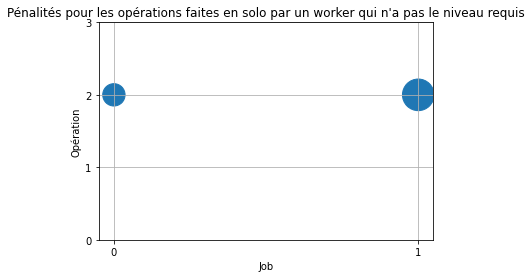

In [109]:
do_solo_without_level(instance_generated, s)

## I.2a On va forcer encore plus en diminuant de 1 le levels de chaque worker

In [110]:
print("Avant de diminuer les niveaux des workers :")
print(instance_generated.levels_workers)

for i in range(len(instance_generated.levels_workers)):
    for j in range(len(instance_generated.levels_workers[i])):
        instance_generated.levels_workers[i][j] = max(1, instance_generated.levels_workers[i][j] - 1)

print("Après avoir diminué les niveaux des workers de 1 :")
print(instance_generated.levels_workers)

Avant de diminuer les niveaux des workers :
[[2 2 2 2]
 [2 2 2 1]
 [3 2 2 2]]
Après avoir diminué les niveaux des workers de 1 :
[[1 1 1 1]
 [1 1 1 1]
 [2 1 1 1]]


In [111]:
instance_generated.qualified_workers_for_task(verbose=True)

J1:  (1,1): [1, 2, 3] 	 (1,2): [] 	 (1,3): [] 	

J2:  (2,1): [1, 2, 3] 	 (2,2): [] 	 (2,3): [] 	



[[[1, 2, 3], [], []], [[1, 2, 3], [], []]]

In [112]:
model = Model(instance_generated)
s = model.solve(objective="makespan", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 7.000701
ici ->  2
nObjectives 2
nSolutions 3


In [83]:
gantt_chart(s, instance_generated, color=3, render= "notebook", verbose=False)

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.000000,11.000000,11.000000,11.000000,"(1,1)",J1,alone,1,1,3.0,1.0
1,w1,15.659642,20.159642,20.159642,4.500000,"(1,3)",J1,alone without levels,1,3,6.0,3.0
2,w2,-0.000000,11.159642,11.159642,11.159642,"(2,1)",J2,collaboratively,1,1,8.0,3.0
3,w2,11.159642,14.159642,14.159642,3.000000,"(2,2)",J2,alone without levels,1,2,7.0,3.0
4,w2,14.159642,20.159642,20.159642,6.000000,"(2,3)",J2,alone without levels,1,4,4.0,2.0
5,w3,0.000000,11.159642,11.159642,11.159642,"(2,1)",J2,collaboratively,1,1,8.0,3.0
6,w3,11.159642,14.159642,14.159642,3.000000,"(1,2)",J1,alone without levels,1,2,7.0,3.0


Opération 1 du job 0 a une pénalité de 1.0007010000000003
Opération 2 du job 0 a une pénalité de 2.0
Opération 1 du job 1 a une pénalité de 1.0
Opération 2 du job 1 a une pénalité de 3.0


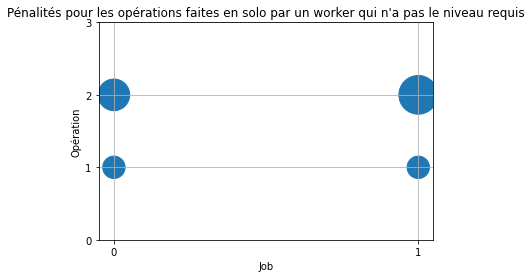

In [113]:
do_solo_without_level(instance_generated, s)

## II. Résolution lexico-graphique

In [114]:
instance_generated = Instance()
instance_generated.from_random(at_least_a_worker_have_competence_for_each_profession=False, seed=2048)
# print(instance_generated)

### II.1 Makespan puis skills, puis cognitive load

In [115]:
model = Model(instance_generated)
s = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 2.000201
ici ->  4
nObjectives 4
nSolutions 8


In [126]:
instance_generated.qualified_workers_for_task(verbose=True)

J1:  (1,1): [6] 	 (1,2): [6] 	 (1,3): [2] 	 (1,4): [2, 5, 6] 	

J2:  (2,1): [2, 5, 6] 	 (2,2): [2] 	 (2,3): [] 	 (2,4): [1, 2, 3, 4, 6] 	

J3:  (3,1): [3, 4, 5, 6] 	 (3,2): [] 	 (3,3): [1, 2, 3, 4, 6] 	 (3,4): [1, 2, 3, 4, 6] 	



[[[6], [6], [2], [2, 5, 6]],
 [[2, 5, 6], [2], [], [1, 2, 3, 4, 6]],
 [[3, 4, 5, 6], [], [1, 2, 3, 4, 6], [1, 2, 3, 4, 6]]]

- On voit qu'il y a des taches qui n'ont pas d'opérateur qualifié 

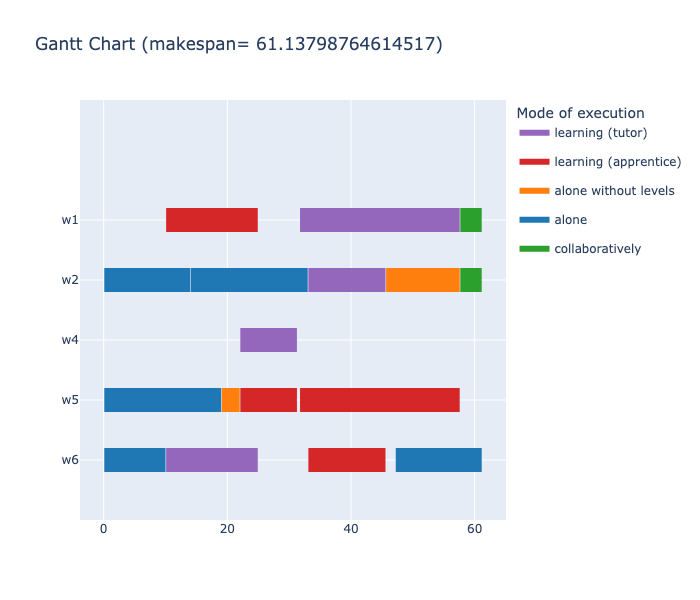

In [122]:
df = gantt_chart(s, instance_generated, color=3, render= "notebook", verbose=False, separate_little=True)

In [123]:
df

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,10.100000,24.919024,24.919024,14.919024,"(1,2)",J1,learning (apprentice),1,3,10.0,3.0
1,w1,31.757876,57.578465,57.578465,25.920590,"(3,4)",J3,learning (tutor),3,2,8.0,2.0
2,w1,57.678465,61.137988,61.137988,3.559522,"(2,4)",J2,collaboratively,3,2,6.0,2.0
3,w2,0.100000,14.000000,14.000000,14.000000,"(2,1)",J2,alone,2,2,9.0,3.0
4,w2,14.100000,33.000000,33.000000,19.000000,"(2,2)",J2,alone,3,3,4.0,1.0
5,w2,33.106114,45.578465,45.578465,12.572351,"(1,3)",J1,learning (tutor),3,3,3.0,1.0
6,w2,45.678465,57.578465,57.578465,12.000000,"(2,3)",J2,alone without levels,3,4,5.0,1.0
7,w2,57.678465,61.137988,61.137988,3.559522,"(2,4)",J2,collaboratively,2,2,6.0,2.0
8,w4,22.100000,31.254810,31.254810,9.254810,"(3,3)",J3,learning (tutor),2,2,6.0,2.0
9,w5,0.100000,19.000000,19.000000,19.000000,"(3,1)",J3,alone,3,2,2.0,0.0


In [124]:
check_df(df)

True

Opération 2 du job 1 a une pénalité de 1.0
Opération 1 du job 2 a une pénalité de 1.0


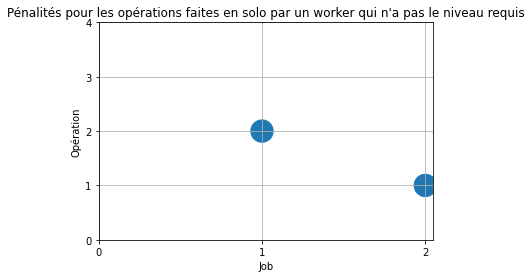

In [125]:
do_solo_without_level(instance_generated, s)

- Le niveau des personnes ayant fait les opération qui n'ont pas de worker compétent avait une difference de 1 avec le niveau de difficulté de la tache

#### **II.1a Affichage des charges cognitives totales par métier**

cognitive_load_total=
[[0.  0.  1.2 0.3]
 [0.  0.7 0.5 0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.7 0. ]
 [0.  0.  0.6 0. ]
 [0.  0.3 0.  0.7]]


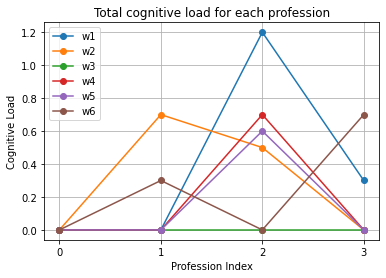

In [118]:
plot_cognitive_load_total(s, instance_generated, verbose=True)

- **le worker $w_1$ est celui qui à la charge cognitive la plus élevée pour le corps de métier 2**
- Après analyse on voit que le worker $w_1$ n'a fait aucune tache seul, il a fait des taches en tant que tuteur, apprentis et en collaboration
- $w_3$ à une charge cognitive de 0 car il n'a fait aucune tache

#### **II.1b Affichage des skills totales par métier et par worker**

levels_workers=
[[[1.  1.  3.  1. ]
  [1.  1.  3.  1.5]]

 [[1.  3.  2.  2. ]
  [1.  3.5 2.  2. ]]

 [[3.  2.  3.  1. ]
  [3.  2.  3.  1. ]]

 [[3.  2.  2.  1. ]
  [3.  2.  2.  1. ]]

 [[3.  2.  1.  2. ]
  [3.5 2.  2.  2. ]]

 [[2.  2.  3.  3. ]
  [2.  2.5 3.  3. ]]]


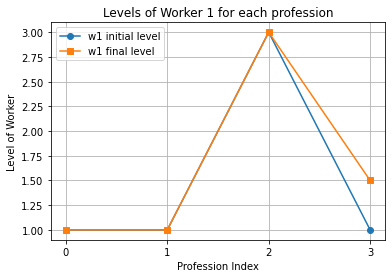

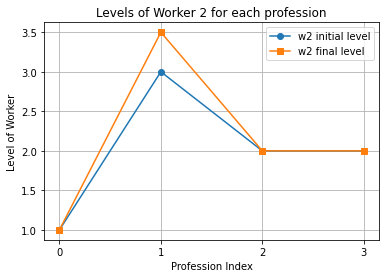

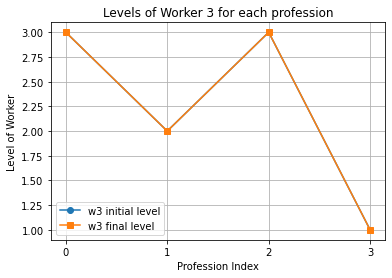

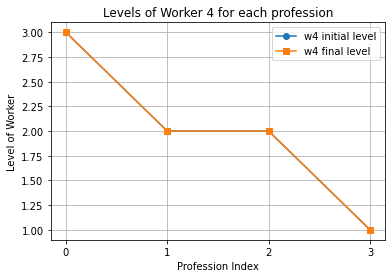

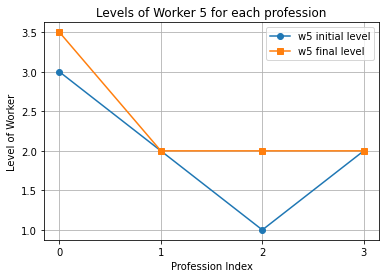

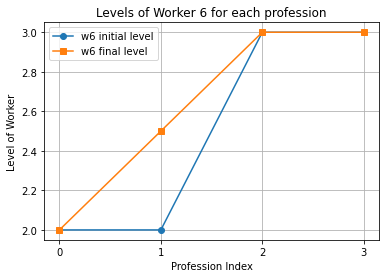

In [127]:
plot_levels_workers(s, instance_generated, verbose=True)

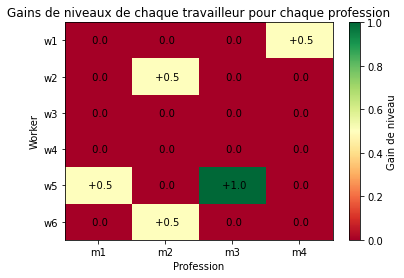

In [129]:
resume_levels_workers(s, instance_generated)

- On peut voir que certains workers on fait des taches en tant que tuteur et sur quelle corps de métier
- Certains n'ont pas eu d'effet d'augmentation de leurs skills, car ils n'ont fait que des taches en collaboration ou en solo
- Un worker deja compétent sur un corps de métier ne verra jamais d'augmentation de ses skills sur ce corsp de métier

## III.A Lexicographic en priorisant les skills

In [131]:
instance_generated = Instance()
instance_generated.from_random(at_least_a_worker_have_competence_for_each_profession=False, seed=2048)
# print(instance_generated)
model = Model(instance_generated)
s = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[1, 2, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 2.000201
ici ->  4
nObjectives 4
nSolutions 9


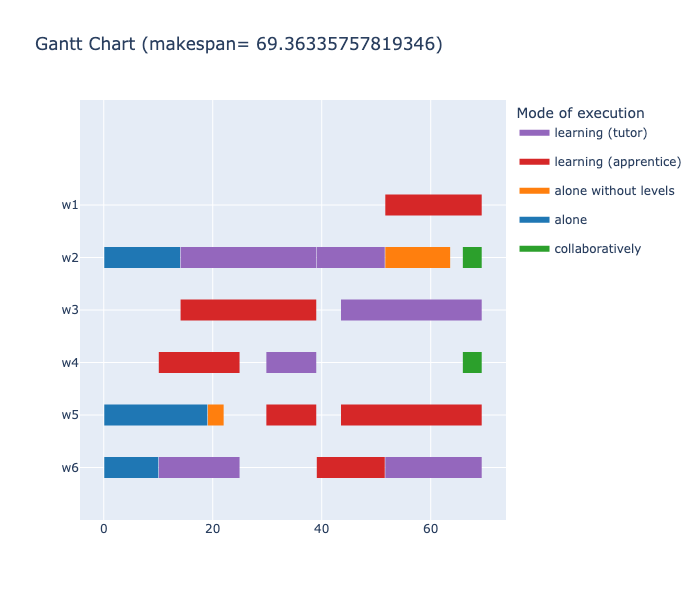

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,51.667835,69.356421,69.356421,17.788586,"(1,4)",J1,learning (apprentice),1,2,9.0,3.0
1,w2,0.100000,14.000000,14.000000,14.000000,"(2,1)",J2,alone,2,2,9.0,3.0
2,w2,14.100000,38.995483,38.995483,24.995483,"(2,2)",J2,learning (tutor),3,3,4.0,1.0
3,w2,39.095483,51.567835,51.567835,12.572351,"(1,3)",J1,learning (tutor),3,3,3.0,1.0
4,w2,51.667835,63.567835,63.567835,12.000000,"(2,3)",J2,alone without levels,3,4,5.0,1.0
5,w2,65.896899,69.356421,69.356421,3.559522,"(2,4)",J2,collaboratively,2,2,6.0,2.0
6,w3,14.100000,38.995483,38.995483,24.995483,"(2,2)",J2,learning (apprentice),2,3,4.0,1.0
7,w3,43.535831,69.356421,69.356421,25.920590,"(3,4)",J3,learning (tutor),3,2,8.0,2.0
8,w4,10.100000,24.919024,24.919024,14.919024,"(1,2)",J1,learning (apprentice),1,3,10.0,3.0
9,w4,29.840674,38.995483,38.995483,9.254810,"(3,3)",J3,learning (tutor),2,2,6.0,2.0


In [133]:
gantt_chart(s, instance_generated, color=3, render= "notebook", verbose=False, separate_little=True)

- Le makespan a augmenté de 10 unité 

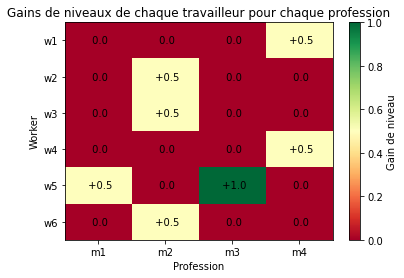

In [134]:
# plot_levels_workers(s, instance_generated, verbose=True)
resume_levels_workers(s, instance_generated, verbose=False)

- La somme des skills a augmenté de 1 unité

cognitive_load_total_per_worker=
[0.3 1.9 1.  1.5 0.6 1.7]


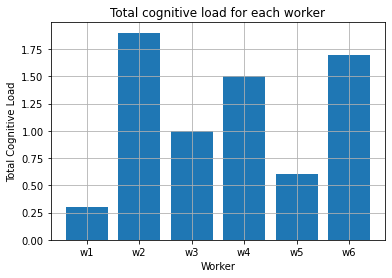

In [135]:
bars_cognitive_load_total(s, instance_generated, verbose=True)